In [239]:
import sys, os
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION']='.9'
import jax_cosmo.background as bkgrd
# os.environ["CUDA_VISIBLE_DEVICES"] = "0"
from jax.lib import xla_bridge
# platform = xla_bridge.get_backend().platform
import jax
print(jax.local_device_count(), jax.device_count())
# jax.config.update('jax_platform_name', platform)
jax.config.update("jax_enable_x64", True)
import jax
# Change the current working directory to the desired path
# os.chdir('/mnt/home/spandey/ceph/GODMAX/src/')

import matplotlib

import matplotlib.pyplot as pl
# set latex to false:
pl.rcParams['text.usetex'] = False
%load_ext autoreload
%autoreload 2
import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
sys.path.append((curr_path))
sys.path.append((abs_path_data))
sys.path.append((abs_path_results))
sys.path.append(abs_path_src)
# import numpyro
# numpyro.set_platform("gpu")
# numpyro.enable_x64()
from jax import config
config.update("jax_enable_x64", True)
import scipy.interpolate as interp
import pickle as pk
import numpy as np
import jax.numpy as jnp
import colossus 
from jax import vmap, grad, pmap
import matplotlib.pyplot as pl
import jax_cosmo.background as bkgrd
import time
from jax_cosmo import Cosmology
from jax_cosmo.background import angular_diameter_distance, radial_comoving_distance
from astropy import constants as const
pl.rc('text', usetex=True)
# Palatino
# pl.rc('font', family='DejaVu Sans')

%matplotlib inline
%load_ext autoreload
%autoreload 2




1 1
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [240]:
import yaml
import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
abs_path_params = os.path.abspath(curr_path / "../../param_files/") 

from deepmerge import always_merger
def read_yaml(file_path):
    with open(file_path, 'r') as file:
        data = yaml.safe_load(file)
    return data

def generate_dicts(data):
    sim_params_dict = data.get('sim_params', {})
    halo_params_dict = data.get('halo_params', {})
    analysis_dict = data.get('analysis', {})
    other_params_dict = data.get('other_params', {})
    return sim_params_dict, halo_params_dict, analysis_dict, other_params_dict

default_data = read_yaml(abs_path_params + '/params_default.yaml')
# sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = generate_dicts(default_data)
new_data = read_yaml(abs_path_params + '/Pge/params.yaml')
# new_data = read_yaml(abs_path_params + '/DESxACT/params_v0.yaml')
merged_data = always_merger.merge(default_data, new_data)

sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = generate_dicts(merged_data)

# analysis_dict['beam_fwhm_arcmin'] = 1.4
df_nz_comoving = np.loadtxt(abs_path_data + '/pge/comoving_nz_bgs_lrg_DESIY3_key_zall.txt')
zarray_comoving = df_nz_comoving[:,0]
nz_comoving_orig = df_nz_comoving[:,1]
indsel = np.where(zarray_comoving < 0.4)[0]
nz_comoving = np.zeros_like(zarray_comoving)
nz_comoving[indsel] = nz_comoving_orig[indsel]*1.0
indsel = np.where(zarray_comoving > 0.4)[0]
nz_comoving[indsel] = nz_comoving_orig[indsel]*1.0
analysis_dict['nbar_gal_comoving_zarray'] = zarray_comoving
analysis_dict['nbar_gal_comoving_val'] = nz_comoving



from scipy.interpolate import interp1d
# ks = np.geomspace(5e-2,50,15) # wavenumbers
ks = np.geomspace(3e-1,10,10) # wavenumbers
zedges = np.array([0.1, 0.4, 0.6, 0.8,1.1])
zarray_lens = np.linspace(0.001, 1.6, 100)
nbins_lens = len(zedges) - 1

cosmo_params = sim_params_dict.get('cosmo')
cosmo_jax = Cosmology(
            Omega_c=cosmo_params['Om0'] - cosmo_params['Ob0'],
            Omega_b=cosmo_params['Ob0'],
            h=cosmo_params['H0'] / 100.,
            sigma8=cosmo_params['sigma8'],
            n_s=cosmo_params['ns'],
            Omega_k=0.,
            w0=cosmo_params['w0'],
            wa=0.
            )
scale_fac_a_array = 1.0 / (1.0 + zarray_lens)
chi_array = radial_comoving_distance(cosmo_jax, scale_fac_a_array)
dchi_dz_array = (const.c.value * 1e-3) / bkgrd.H(cosmo_jax, scale_fac_a_array)
nz_comoving_interp = interp1d(zarray_comoving, nz_comoving, fill_value=1e-20, bounds_error=False)
nz_comoving_zarray = nz_comoving_interp(zarray_lens)
nz_zarray = nz_comoving_zarray * (chi_array**2 * dchi_dz_array)
nz_zarray = nz_zarray/(np.trapz(nz_zarray, zarray_lens))
nz_lens = {}
for jb in range(nbins_lens):
    nz_jb = np.zeros_like(nz_zarray)
    indsel = np.where((zarray_lens > zedges[jb]) & (zarray_lens < zedges[jb+1]))[0]
    nz_jb[indsel] = nz_zarray[indsel]
    norm_val = np.trapz(nz_jb, zarray_lens)
    nz_jb = nz_jb/norm_val
    nz_lens[jb] = nz_jb

nz_info_dict = {}
nz_info_dict['z_array_lens'] = zarray_lens
nz_info_dict['nbins_lens'] = nbins_lens
for ji in range(nz_info_dict['nbins_lens']):
    nz_info_dict['nz'+str(ji)] = np.maximum(nz_lens[ji], 1e-3)
analysis_dict['nz_lens_info_dict'] = nz_info_dict


from astropy.io import fits
df = fits.open(os.path.abspath(abs_path_data + '/forecast/lsst_simulate_Y1.fits'))
z_array = df['nz_source'].data['Z_MID']
nz_info_dict = {}
nz_info_dict['z_array_source'] = z_array
nz_info_dict['nbins'] = 5
for ji in range(nz_info_dict['nbins']):
    nz_info_dict['nz'+str(ji)] = np.maximum(df['nz_source'].data['BIN'+str(ji+1)], 1e-4)
analysis_dict['nz_source_info_dict'] = nz_info_dict
other_params_dict['Delta_z_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])
other_params_dict['mult_shear_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])
# analysis_dict['sigma_epsilon_SN_bins'] = [0.367, 0.367, 0.367, 0.367, 0.367]/np.sqrt(2)
# # analysis_dict['neff_arcmin2_SN_bins'] = [2.24,2.24,2.24,2.24,2.24] * 2
# analysis_dict['neff_arcmin2_SN_bins'] = [4.64, 4.64, 4.64, 4.64, 4.64]


analysis_dict['angles_data_array'] = df['xip'].data['ANG'][0:20]


analysis_dict['k_array_survey'] = jnp.array(ks / (sim_params_dict['cosmo']['H0']/100.))

lmin, lmax, dl_log_array = 80.0, 8800.0, 0.23025851
l_array_all = np.exp(np.arange(np.log(lmin), np.log(lmax), dl_log_array))
dl_array = l_array_all[1:] - l_array_all[:-1]
l_array_survey = (l_array_all[1:] + l_array_all[:-1]) / 2.
halo_params_dict['ell_array'] = jnp.array(l_array_survey)
analysis_dict['l_array_survey'] = jnp.array(l_array_survey)
analysis_dict['dl_array_survey'] = jnp.array(dl_array)
analysis_dict['yy_noise_ell_fname'] = os.path.abspath(abs_path_data + '/pge/Noise_fid_yy_beamed_1p4arcmin.txt')

Ngals_bins = []
Vol_Gpc3 = []
z_cens = []
P0 = 9e3
fsky_DESIxDESI = analysis_dict['fsky_gg']
for jb in range(nbins_lens):
    nz_jb_only = np.copy(nz_comoving_zarray)
    indsel = np.where((zarray_lens < zedges[jb]) | (zarray_lens > zedges[jb+1]))[0]
    nz_jb_only[indsel] = 0.0
    nz_integrate = np.trapz(nz_jb_only*(chi_array**2)*dchi_dz_array, zarray_lens)

    ntot_jb = nz_integrate*4*np.pi*fsky_DESIxDESI
    Ngals_bins.append(ntot_jb)

    zmean = np.trapz(zarray_lens*nz_jb_only*(chi_array**2)*dchi_dz_array, zarray_lens)/nz_integrate
    z_cens.append(zmean)

    fsky_nz = np.ones_like(zarray_lens)
    fsky_nz[indsel] = 0.0
    fsky_nz_desi = fsky_nz * (nz_jb_only*P0/(1 + nz_jb_only*P0))**2
    h3 = (sim_params_dict['cosmo']['H0'] / 100.0)**3
    Vol_Gpc3_comoving = 4*np.pi*fsky_DESIxDESI*np.trapz(fsky_nz * (chi_array**2)*dchi_dz_array, zarray_lens)/(h3 * 1e9)   
    Vol_Gpc3_comoving_desi = 4*np.pi*fsky_DESIxDESI*np.trapz(fsky_nz_desi * (chi_array**2)*dchi_dz_array, zarray_lens)/(h3 * 1e9)   

    Vol_Gpc3.append(Vol_Gpc3_comoving_desi)
    print(zedges[jb], zedges[jb+1], 'Total galaxies = {:.2f}'.format(ntot_jb), ' Vol:', Vol_Gpc3_comoving_desi)
    # print('Bin {}: Total galaxies = {:.2f}'.format(jb, ntot_jb))
    

Ngals_bins, Vol_Gpc3, z_cens = np.array(Ngals_bins), np.array(Vol_Gpc3), np.array(z_cens)
    
    # Ngals_bins = 3.33*np.array([506905, 771875, 859824])
analysis_dict['nbar_lens_bins'] = Ngals_bins/(analysis_dict['fsky_gg']*41253*(60**2))

analysis_dict['symbolic_pk'] = True
analysis_dict['symbolic_hmf'] = True

# analysis_dict['symbolic_pk'] = False
# analysis_dict['symbolic_hmf'] = False




0.1 0.4 Total galaxies = 2094335.24  Vol: 5.48821108191444
0.4 0.6 Total galaxies = 2238124.27  Vol: 9.547174515203288
0.6 0.8 Total galaxies = 3190997.73  Vol: 13.706697159070595
0.8 1.1 Total galaxies = 3757239.75  Vol: 20.10026768637848


/tmp/ipykernel_652617/4104816934.py:68: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  nz_zarray = nz_zarray/(np.trapz(nz_zarray, zarray_lens))
/tmp/ipykernel_652617/4104816934.py:74: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm_val = np.trapz(nz_jb, zarray_lens)
/tmp/ipykernel_652617/4104816934.py:125: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  nz_integrate = np.trapz(nz_jb_only*(chi_array**2)*dchi_dz_array, zarray_lens)
/tmp/ipykernel_652617/4104816934.py:130: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  zmean = np.trapz(zarray_lens*nz_jb_only*(chi_array**2)*dchi_dz_array, zarray_lens)/nz_integrate
/tmp/ipykernel_

In [241]:
from godmax.base_class import base_class
from godmax.get_radial_profiles import Profiles
from godmax.get_Pkzs import get_Pkz
from godmax.get_Cls import get_Cl
from godmax.get_Xis import get_xi
from godmax.get_covs import get_cov
import matplotlib.pyplot as pl

base_test = base_class(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)
profiles_test = Profiles(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, base_class_obj=base_test)
Pkz_test = get_Pkz(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Profiles_obj=profiles_test)




In [242]:
from __future__ import print_function
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import os,sys
sys.path.append(os.path.abspath('/projects/bdne/spandey3/Pge_GODMAX/hmvec'))
# hmvec_path = os.path.abspath(abs_path_src + "../../../hmvec/") 
# sys.path.append(hmvec_path)
import hmvec as hm # Git clone and pip install as in readme from github.com/msyriac/hmvec
import numpy as np
import time

# cosmo_colossus = {'flat': True, 'H0': 67.66, 'Om0': 0.3111, 'Ob0': 0.0490, 'sigma8': 0.8102, 'ns': 0.9665}
cosmo_colossus = sim_params_dict['cosmo']
h = cosmo_colossus['H0']/100
omch2 = (cosmo_colossus['Om0']-cosmo_colossus['Ob0'])*h**2
ombh2 = cosmo_colossus['Ob0']*h**2
ns = cosmo_colossus['ns']
import camb
lmax = 20000
pars = camb.CAMBparams(max_l=lmax)
pars.set_cosmology(H0=h*100,
                ombh2=ombh2,
                omch2=omch2,
                mnu=0.0,
                omk=0,
                )
pars.set_for_lmax(lmax, lens_potential_accuracy=1)
# As_fid = hcos.params['As']
As_fid = 2.1e-9
pars.InitPower.set_params(As=As_fid, ns=ns, r=0)
redshifts_all = np.linspace(0, 2, 100)
pars.set_matter_power(redshifts=redshifts_all, kmax=1000)
pars.NonLinear = camb.model.NonLinear_none
results = camb.get_results(pars)
sigma8_all = results.get_sigma8()
sigma8_camb = sigma8_all[-1]
print(f"sigma8 orig from camb is {sigma8_camb}")
As_new = As_fid*(cosmo_colossus['sigma8']/sigma8_camb)**2

cosmo_params = {'omch2': omch2,
    'ombh2': ombh2,
    'H0': cosmo_colossus['H0'],
    'ns': cosmo_colossus['ns'],
    'As': As_new
    }

zgalaxy = 0.01 # delta-function lens population
zsource = 1.0 # delta-function source population
ngal = 1e-4 # number density of lenses per mpc3 (to solve for stellar mass threshold in HOD)

# We set up the grid to integrate on
zmax = zsource + 1
numzs = 20
zs = np.linspace(0.01,zmax,numzs) # redshifts
ms = np.geomspace(2e10,1e17,100) # masses
# ks = np.geomspace(5e-2,50,15) # wavenumbers
# ks = np.geomspace(1e-2,20,10) # wavenumbers

# Initialize halo model
hcos = hm.HaloModel(zs,ks,ms=ms, params=cosmo_params)
# We add an HOD which should be CMASS-like at z=zgalaxy
hcos.add_hod("g",ngal=ngal+zs*0.,corr="max")
print("Galaxy bias at zgalaxy=",zgalaxy, " is ",interp1d(zs,hcos.hods['g']['bg'])(zgalaxy))
# We add a gas profile
a = time.time()
hcos.add_battaglia_profile("electron",family="AGN",xmax=50,nxs=30000)
b = time.time()-a
print(f"Profile took {b} seconds.")

"""
Galaxy-galaxy lensing
"""
Pgn = hcos.get_power("g","nfw",verbose=False)
Pge = hcos.get_power("g","electron",verbose=False )
Pgm = hcos.total_matter_galaxy_power_spectrum(Pgn,Pge)
Pgg = hcos.get_power("g","g",verbose=False)

ns=hcos.params['ns']
Om=(hcos.params['omch2']+hcos.params['ombh2'])/hcos.h**2
Ob=(hcos.params['ombh2'])/hcos.h**2
h=hcos.h
import camb
lmax = 20000
pars = camb.CAMBparams(max_l=lmax)
pars.set_cosmology(H0=h*100,
                ombh2=Ob * h ** 2,
                omch2=(Om - Ob) * h ** 2,
                mnu=0.0,
                omk=0,
                )
pars.set_for_lmax(lmax, lens_potential_accuracy=1)
As_fid = hcos.params['As']
pars.InitPower.set_params(As=As_fid, ns=ns, r=0)
redshifts_all = np.linspace(0, 2, 100)
pars.set_matter_power(redshifts=redshifts_all, kmax=1000)
pars.NonLinear = camb.model.NonLinear_none
results = camb.get_results(pars)
sigma8_all = results.get_sigma8()
sigma8_camb = sigma8_all[-1]
print(f"sigma8 from camb is {sigma8_camb}")




Note: redshifts have been re-sorted (earliest first)
sigma8 orig from camb is 0.7986254489067204
Bisection search converged in  19  iterations.
Galaxy bias at zgalaxy= 0.01  is  1.577244955438505


/projects/bdne/spandey3/Pge_GODMAX/hmvec/hmvec.py:724: RuntimeWarning: invalid value encountered in divide
  ret = Ns**2./Nc
/projects/bdne/spandey3/Pge_GODMAX/hmvec/fft.py:91: RuntimeWarning: invalid value encountered in divide
  uk = ukts/kts[None,None,:]/mnorm[...,None]


Profile took 2.1932034492492676 seconds.
Note: redshifts have been re-sorted (earliest first)
sigma8 from camb is 0.8000000000000004


In [243]:
Cl_cmb = results.get_cmb_power_spectra(pars, lmax=lmax, CMB_unit='muK', raw_cl=True)['total'][:,0]
ell_cmb = np.arange(Cl_cmb.shape[0])

df = np.loadtxt(abs_path_data + '/pge/SO_LAT_Nell_T_atmv1_goal_fsky0p4_ILC_CMB.txt')
# df.shape
ell_noise = df[:,0]
Nell_T = df[:,1]
Nell_interp = interp1d(np.log(ell_noise),np.log(np.clip(Nell_T, 1e-10, 1e10)),bounds_error=False,fill_value='extrapolate')
Nell_T = np.exp(Nell_interp(np.log(ell_cmb)))
Nell_T[0] = Nell_T[1]

df_ksz = np.loadtxt(abs_path_data + '/pge/ksz_autopower_webksky_muK2.txt')
ell_ksz = df_ksz[:,0]
Cl_ksz = df_ksz[:,1]
# Cl_ksz[0] = Cl_ksz[1]
# print(Cl_ksz)

Cl_ksz_interp = interp1d(np.log(ell_ksz),np.log(np.clip(Cl_ksz, 1e-20, 1e20)),bounds_error=False,fill_value='extrapolate')
Cl_ksz = np.exp(Cl_ksz_interp(np.log(ell_cmb)))
Cl_ksz[0] = 1e-11
Cl_ksz[1] = 1e-11


Cl_tot = Cl_cmb + Nell_T + Cl_ksz



/tmp/ipykernel_652617/817223050.py:9: RuntimeWarning: divide by zero encountered in log
  Nell_T = np.exp(Nell_interp(np.log(ell_cmb)))
/tmp/ipykernel_652617/817223050.py:18: RuntimeWarning: divide by zero encountered in log
  Cl_ksz_interp = interp1d(np.log(ell_ksz),np.log(np.clip(Cl_ksz, 1e-20, 1e20)),bounds_error=False,fill_value='extrapolate')
/tmp/ipykernel_652617/817223050.py:19: RuntimeWarning: divide by zero encountered in log
  Cl_ksz = np.exp(Cl_ksz_interp(np.log(ell_cmb)))
/u/spandey3/.local/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:482: RuntimeWarning: invalid value encountered in subtract
  y_new = slope*(x_new - x_lo)[:, None] + y_lo
/u/spandey3/.local/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:482: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


(1e-11, 10000)

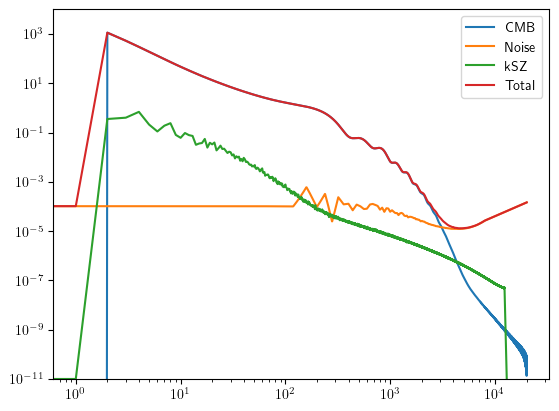

In [244]:
pl.figure()
pl.loglog(ell_cmb,Cl_cmb,label='CMB')
pl.loglog(ell_cmb,Nell_T,label='Noise')
pl.loglog(ell_cmb,Cl_ksz,label='kSZ')
pl.loglog(ell_cmb,Cl_tot,label='Total')
pl.legend()
# pl.ylim(1e-11, 100)
pl.ylim(1e-11, 10000)



In [245]:
# zedges = np.array([0.4, 0.6, 0.8,1.1])
# Ngals_bins = 3.33*np.array([506905, 771875, 859824])
# Ngals_tot = np.sum(Ngals_bins)
# Vol_Gpc3 = (14000/5840)*np.array([2.6, 4.0, 5.0])
# z_cens = np.array([0.51, 0.71, 0.92])
Vol_Mpc3 = Vol_Gpc3*1e9
ngal_mpc3 = Ngals_bins/Vol_Mpc3

import ksz
ksz_obj = ksz.kSZ(z_cens, Vol_Gpc3, ngal_mpc3, params=cosmo_params,engine='camb')

logkcens = np.log(ks)
dlogk = logkcens[1]-logkcens[0]
logk_edges = logkcens - dlogk/2
logk_edges = np.append(logk_edges,logk_edges[-1]+dlogk)
ks_bin_edges = np.exp(logk_edges)

# hmvec gives results in Mpc, we need Mpc/h units
Pge_err_z0 = np.nan_to_num(ksz_obj.Pge_err(0,ks_bin_edges,Cl_tot), nan=1e5, posinf=1e5, neginf=1e5)
Pge_err_z1 = np.nan_to_num(ksz_obj.Pge_err(1,ks_bin_edges,Cl_tot), nan=1e5, posinf=1e5, neginf=1e5)
Pge_err_z2 = np.nan_to_num(ksz_obj.Pge_err(2,ks_bin_edges,Cl_tot), nan=1e5, posinf=1e5, neginf=1e5)
Pge_err_z3 = np.nan_to_num(ksz_obj.Pge_err(3,ks_bin_edges,Cl_tot), nan=1e5, posinf=1e5, neginf=1e5)


# ks were in Mpc, convert to h/Mpc:
Pge_err_z0_interp = interp1d(np.log(ks),np.log(Pge_err_z0),bounds_error=False,fill_value='extrapolate')
Pge_err_z1_interp = interp1d(np.log(ks),np.log(Pge_err_z1),bounds_error=False,fill_value='extrapolate')
Pge_err_z2_interp = interp1d(np.log(ks),np.log(Pge_err_z2),bounds_error=False,fill_value='extrapolate')
Pge_err_z3_interp = interp1d(np.log(ks),np.log(Pge_err_z3),bounds_error=False,fill_value='extrapolate')

h = cosmo_colossus['H0']/100
ks_wh = ks / h
Pge_err_z0_wh = np.exp(Pge_err_z0_interp(np.log(ks_wh))) * h**3
Pge_err_z1_wh = np.exp(Pge_err_z1_interp(np.log(ks_wh))) * h**3
Pge_err_z2_wh = np.exp(Pge_err_z2_interp(np.log(ks_wh))) * h**3
Pge_err_z3_wh = np.exp(Pge_err_z3_interp(np.log(ks_wh))) * h**3




Bisection search converged in  19  iterations.


/projects/bdne/spandey3/Pge_GODMAX/hmvec/ksz.py:171: UserWarning: Using equal k_min at each z, despite different volumes at each z
  warnings.warn('Using equal k_min at each z, despite different volumes at each z')


Note: redshifts have been re-sorted (earliest first)


/projects/bdne/spandey3/Pge_GODMAX/hmvec/ksz.py:57: RuntimeWarning: divide by zero encountered in power
  return (volume * kstar**2 / 12 / np.pi**3 / chistar**2. * pgv_int * np.asarray(ints))**(-0.5)


(0.1, 20)

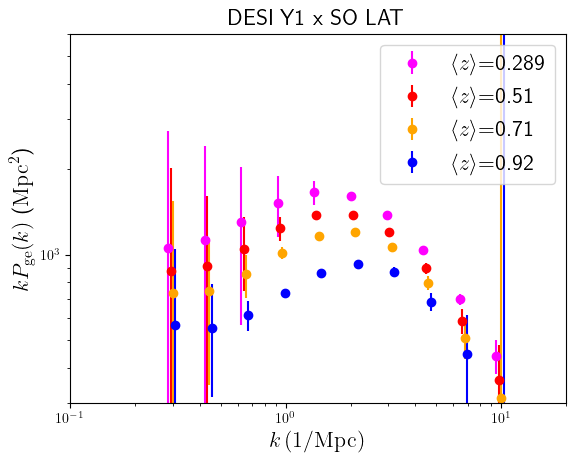

In [246]:
pl.rc('text', usetex=True)
from matplotlib import cm, colorbar
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
dsfac = 1

indz = np.argmin(np.abs(zs - z_cens[0]))
pl.errorbar(0.95*ks[::dsfac],(ks*Pge[indz])[::dsfac], (ks*Pge_err_z0)[::dsfac],label=r'$\langle z \rangle$=0.289', color='magenta', ls='', marker='o')

indz = np.argmin(np.abs(zs - z_cens[1]))
pl.errorbar(0.975*ks[::dsfac],(ks*Pge[indz])[::dsfac], (ks*Pge_err_z1)[::dsfac],label=r'$\langle z \rangle$=0.51', color='red', ls='', marker='o')

indz = np.argmin(np.abs(zs - z_cens[2]))
pl.errorbar(ks[::dsfac],(ks*Pge[indz])[::dsfac], (ks*Pge_err_z2)[::dsfac],label=r'$\langle z \rangle$=0.71', color='orange', ls='', marker='o')

indz = np.argmin(np.abs(zs - z_cens[3]))
pl.errorbar(1.025*ks[::dsfac],(ks*Pge[indz])[::dsfac], (ks*Pge_err_z3)[::dsfac],label=r'$\langle z \rangle$=0.92', color='blue', ls='', marker='o')



pl.title('DESI Y1 x SO LAT', fontsize=16)
pl.ylim(3e2, 6e3)
pl.legend(fontsize=16)
pl.xscale('log')
pl.yscale('log')
pl.xlabel(r'$k \,  (1/{\rm Mpc})$', fontsize=16)
pl.ylabel(r'$kP_{\rm ge}(k)$ (${\rm Mpc}^2$)', fontsize=16)
pl.xlim(0.1, 20)





In [247]:
# from get_power_spectra import get_power_BCMP
# get_power_test = get_power_BCMP(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)
from godmax.get_covs import get_cov
cov_test = get_cov(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)




In [248]:
probes_all = ['ky', 'kk', 'gy', 'gg', 'gk']

bin_comb_all_wprobe = []
count_all_probes = 0
count_probes_array = []
for jp in range(len(probes_all)):
    count_probe_jp = 0
    probe = probes_all[jp]
    bin_comb_all = cov_test.Cl_result_dict[probe]['bin_combs']
    
    # bin_comb_sel = []
    for bin_comb in bin_comb_all:
        bin1 = bin_comb[0]
        bin2 = bin_comb[1]
        if probe in ['kk']: 
            if bin2 >= bin1:
                bin_comb_all_wprobe.append([probe,[bin1, bin2]])
                count_all_probes += 1
                count_probe_jp += 1
        elif probe in ['gg']:
            if bin2 == bin1:
                bin_comb_all_wprobe.append([probe,[bin1, bin2]])
                count_all_probes += 1
                count_probe_jp += 1
        else:
            bin_comb_all_wprobe.append([probe,[bin1, bin2]])
            count_all_probes += 1
            count_probe_jp += 1
    count_probes_array.append(count_probe_jp)

print(count_all_probes)




48


In [249]:
count_all_probes, count_probes_array


(48, [5, 15, 4, 4, 20])

In [250]:
# bin_comb_all_wprobe
# ky --> 4, kk --> 10, gy --> 3, gg --> 6, gk --> 12


In [251]:
nell = len(l_array_survey)
nell_all = nell * count_all_probes 

nbl = analysis_dict['nz_lens_info_dict']['nbins_lens']
nk = len(analysis_dict['k_array_survey'])
cov_mat_all = np.zeros((nell_all + nbl*nk, nell_all + nbl*nk))
for jp1 in range(len(bin_comb_all_wprobe)):
    for jp2 in range(len(bin_comb_all_wprobe)):
        binwprobe1 = bin_comb_all_wprobe[jp1]
        binwprobe2 = bin_comb_all_wprobe[jp2]        
        probe1 = binwprobe1[0]
        probe2 = binwprobe2[0]
        bin_comb1 = binwprobe1[1]
        bin_comb2 = binwprobe2[1]
        b1, b2 = bin_comb1[0], bin_comb1[1]
        b3, b4 = bin_comb2[0], bin_comb2[1]
        try:
            cov_mat_all[jp1*nell:(jp1+1)*nell, jp2*nell:(jp2+1)*nell] = cov_test.covtot_dict[f'{probe1}_{probe2}'][f'bin_{b1}_{b2}_{b3}_{b4}']
        except:
            # cov_mat_all[jp1*nell:(jp1+1)*nell, jp2*nell:(jp2+1)*nell] = cov_test.covtot_dict[f'{probe2}_{probe1}'][f'bin_{b3}_{b4}_{b1}_{b2}']
            pass

cov_mat_all[nell_all:(nell_all+nk), nell_all:(nell_all+nk)] = np.clip(Pge_err_z0_wh, 1e-10, 1e10)**2 * np.eye(nk)
cov_mat_all[nell_all+nk:(nell_all+2*nk), nell_all+nk:(nell_all+2*nk)] = np.clip(Pge_err_z1_wh, 1e-10, 1e10)**2 * np.eye(nk)
cov_mat_all[nell_all+2*nk:(nell_all+3*nk), nell_all+2*nk:(nell_all+3*nk)] = np.clip(Pge_err_z2_wh, 1e-10, 1e10)**2 * np.eye(nk)
cov_mat_all[nell_all+3*nk:(nell_all+4*nk), nell_all+3*nk:(nell_all+4*nk)] = np.clip(Pge_err_z3_wh, 1e-10, 1e10)**2 * np.eye(nk)
            

            

In [252]:
cov_mat_all[nell_all:(nell_all+4*nk),:] = np.maximum(cov_mat_all[nell_all:(nell_all+4*nk),:], 1e-80)
cov_mat_all[:,nell_all:(nell_all+4*nk)] = np.maximum(cov_mat_all[:,nell_all:(nell_all+4*nk)], 1e-80)



In [253]:
cov_mat_copy = np.copy(cov_mat_all)
for i in range(cov_mat_copy.shape[0]):
    for j in range(i + 1, cov_mat_copy.shape[1]):  # Iterate over upper triangle (i < j)
         cov_mat_copy[j, i] = cov_mat_copy[i, j]
cov_mat_all = cov_mat_copy
# pl.figure()
# pl.imshow(np.log(np.abs(cov_mat_copy)), origin='lower')





In [254]:
# # pl.figure()
# # np.real(eigenvectors[-1])
# # def nearest_positive_definite(matrix):
# cov_total_origp = np.copy(cov_mat_copy)
# cov_total = np.copy(cov_mat_copy)

# matrix_pd = np.copy(cov_total)

# # # Step 1: Symmetrize the matrix
# # B = (matrix + matrix.T) / 2

# # # Step 2: Compute the singular value decomposition (SVD)
# # _, s, V = np.linalg.svd(B)

# # # Step 3: Reconstruct the matrix
# # H = V.T @ np.diag(s) @ V

# # # Step 4: Symmetrize again
# # matrix_pd = (B + H) / 2

# # # Step 5: Ensure symmetry
# # matrix_pd = (matrix_pd + matrix_pd.T) / 2

# # Step 6: Correct small eigenvalues
# # Ensure all eigenvalues are positive
# eigvals = np.linalg.eigvals(matrix_pd)
# min_eigval = np.min(eigvals)
# print(min_eigval)
# # if min_eigval < 0:
# #     matrix_pd += np.eye(matrix.shape[0]) * (-min_eigval + 1e-30)

#     # return matrix_pd


In [255]:
# np.min(np.linalg.eigvals(B)), np.min(np.linalg.eigvals(H))



In [256]:

# # cov_total = 0.5*(cov_total + cov_total.T)
# # eigenvalues, eigenvectors = np.linalg.eig(cov_total)
# # epsilon = 1e-1
# # clipped_eigenvalues = (np.maximum((eigenvalues), epsilon))
# # print(np.amin(clipped_eigenvalues))
# # cov_total = eigenvectors @ np.diag(clipped_eigenvalues) @ eigenvectors.T
# # # cov_total = 0.5*(cov_total + cov_total.T)
# # cov_total = np.real(cov_total)
# # # np.fill_diagonal(cov_total, np.diag(cov_total_origp))
# # cov_total = 0.5*(cov_total + cov_total.T)
# cov_total = nearest_positive_definite(cov_total)
# # print(np.linalg.cond(cov_total))
# print(np.linalg.cholesky(cov_total))
# # eigvals = jnp.linalg.eigvals(cov_total)
# # print(jnp.amin(eigvals))
# # P_total = jnp.linalg.inv(cov_total)
# # print(jnp.linalg.cond(cov_total))
# pl.figure()
# # pl.plot(np.diag(cov_total)/np.diag(cov_total_orig))
# pl.plot(np.diag(cov_total))
# pl.plot(np.diag(cov_total_origp))
# pl.yscale('log')
# pl.xlim(0, 100)
# # pl.ylim(1e-37, 1e-25)



In [257]:
l_array_survey = analysis_dict['l_array_survey']
import interpax
ell_yy_noise, Cl_yy_noise = np.loadtxt(analysis_dict['yy_noise_ell_fname'], unpack = True)
log_Cl_yy_noise_interp = interpax.Interpolator1D(
    jnp.log(ell_yy_noise), jnp.log(jnp.abs(Cl_yy_noise)) + 1e-25, extrap=[Cl_yy_noise[0], Cl_yy_noise[-1]]
)
noise_yy = jnp.exp(log_Cl_yy_noise_interp(jnp.log(l_array_survey)))


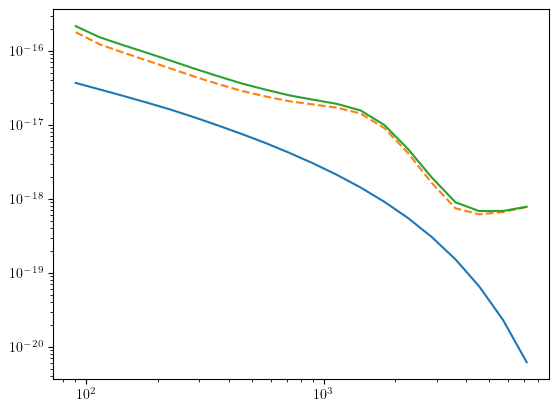

In [258]:
pl.figure()
pl.plot(l_array_survey, cov_test.Cl_result_dict['yy']['bin_' + '0_0']['tot_ellsurvey'])
pl.plot(l_array_survey, noise_yy, ls='--')
pl.plot(l_array_survey, cov_test.Cl_result_dict['yy']['bin_' + '0_0']['tot_plus_noise_ellsurvey'])
pl.yscale('log')
pl.xscale('log')




In [259]:
probe_boundaries = np.array(count_probes_array)
probe_boundaries_cs = np.cumsum(probe_boundaries)
probe_boundaries_center = probe_boundaries_cs - (probe_boundaries/2)
# print(probe_boundaries_cs)
probe_boundaries_edge_right = probe_boundaries_cs
probe_boundaries_edge_left = probe_boundaries_cs - probe_boundaries
ell_edge_left = nell*probe_boundaries_edge_left
ell_edge_right = nell*probe_boundaries_edge_right
probes_all.append('ge')
ell_edge_left = np.append(ell_edge_left, ell_edge_right[-1])
ell_edge_right = np.append(ell_edge_right, ell_edge_right[-1] + 3*nk)




In [260]:
# nell
# ell_array
probe_boundaries



array([ 5, 15,  4,  4, 20])

In [261]:
# cov_mat_all[0,:]


([<matplotlib.axis.YTick at 0xffe538131d50>,
 [Text(0, 50.0, '$\\langle \\kappa y \\rangle$'),
  Text(0, 250.0, '$\\langle \\kappa \\kappa  \\rangle$'),
  Text(0, 440.0, '$\\langle g y \\rangle$'),
  Text(0, 520.0, '$\\langle gg \\rangle$'),
  Text(0, 760.0, '$\\langle g \\kappa \\rangle$'),
  Text(0, 975.0, '$\\langle g e \\rangle$')])

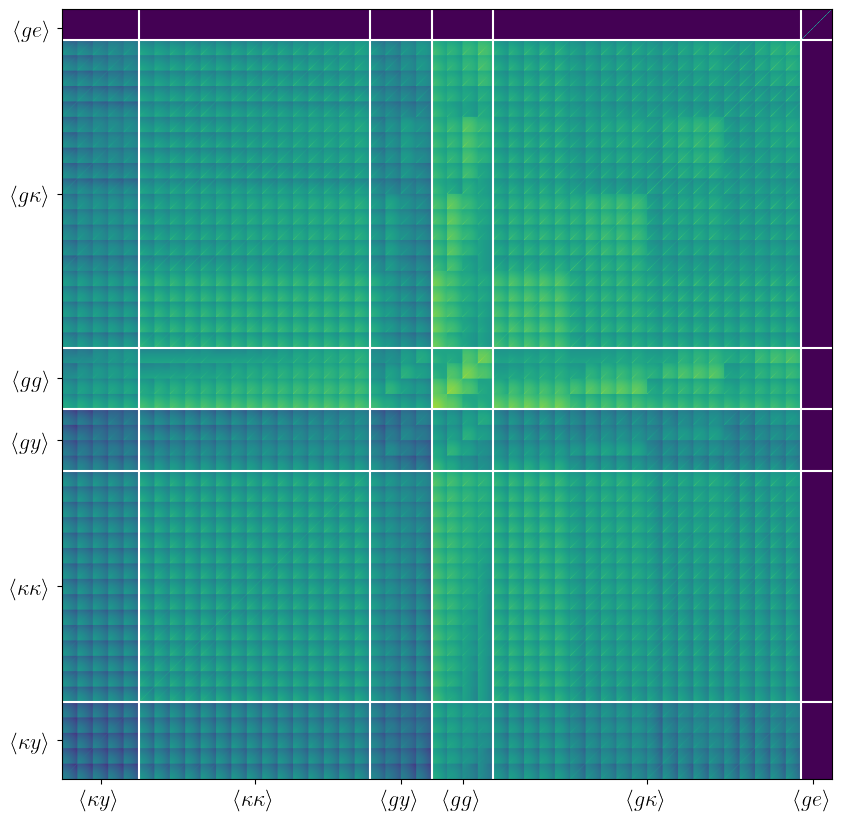

In [262]:
pl.figure(figsize=(10,10))
pl.imshow(np.log(np.abs(cov_mat_all + 1e-70)), origin='lower', vmin=-100, vmax=-20)
pl.axhline(probe_boundaries_cs[0]*nell, color='white')
pl.axhline(probe_boundaries_cs[1]*nell, color='white')
pl.axhline(probe_boundaries_cs[2]*nell, color='white')
pl.axhline(probe_boundaries_cs[3]*nell, color='white')
pl.axhline(probe_boundaries_cs[4]*nell, color='white')

pl.axvline(probe_boundaries_cs[0]*nell, color='white')
pl.axvline(probe_boundaries_cs[1]*nell, color='white')
pl.axvline(probe_boundaries_cs[2]*nell, color='white')
pl.axvline(probe_boundaries_cs[3]*nell, color='white')
pl.axvline(probe_boundaries_cs[4]*nell, color='white')

# write custom text as x-axis labels at a given tick values:
# pl.xticks(probe_boundaries_center*nell, ['ky', 'kk', 'gy', 'gg', 'gk'], fontsize=16)
ticks_loc = np.append(probe_boundaries_center*nell, [probe_boundaries_cs[-1]*nell + 1.5*nk])
pl.xticks(ticks_loc, [r'$\langle \kappa y \rangle$', r'$\langle \kappa \kappa  \rangle$', r'$\langle g y \rangle$', r'$\langle gg \rangle$', r'$\langle g \kappa \rangle$', r'$\langle g e \rangle$'], fontsize=16)
pl.yticks(ticks_loc, [r'$\langle \kappa y \rangle$', r'$\langle \kappa \kappa  \rangle$', r'$\langle g y \rangle$', r'$\langle gg \rangle$', r'$\langle g \kappa \rangle$', r'$\langle g e \rangle$'], fontsize=16)
# pl.imshow(cov_mat_all[1050:,1050:], origin='lower')
# pl.savefig(abs_path_results + '/Pge/plots/cov_mat_all_new_FINAL_v0.pdf', bbox_inches='tight', dpi=300)




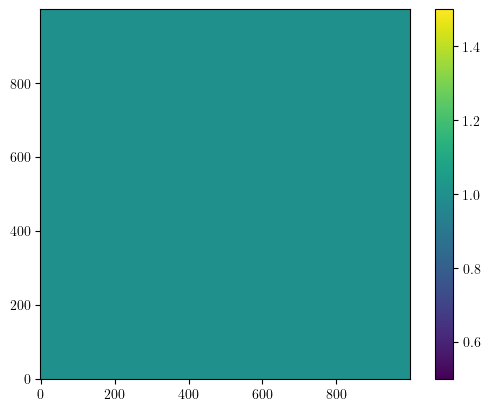

In [263]:
# np.linalg.cond(cov_mat_all)
pl.figure()
pl.imshow(cov_mat_all/(0.5*(cov_mat_all + cov_mat_all.T)), origin='lower', vmin=0.5, vmax=1.5)
pl.colorbar()



In [264]:
Cl_all = np.zeros((nell_all + nbl*nk))
for jp1 in range(len(bin_comb_all_wprobe)):
    binwprobe1 = bin_comb_all_wprobe[jp1]
    probe1 = binwprobe1[0]
    bin_comb1 = binwprobe1[1]
    b1, b2 = bin_comb1[0], bin_comb1[1]
    Cl_all[jp1*nell:(jp1+1)*nell] = cov_test.Cl_result_dict[f'{probe1}'][f'bin_{b1}_{b2}']['tot_ellsurvey']

Cl_all[nell_all:nell_all+nk] = cov_test.Pge_tot_mat[0,:]
Cl_all[nell_all+nk:nell_all+2*nk] = cov_test.Pge_tot_mat[1,:]
Cl_all[nell_all+2*nk:nell_all+3*nk] = cov_test.Pge_tot_mat[2,:]
Cl_all[nell_all+3*nk:nell_all+4*nk] = cov_test.Pge_tot_mat[3,:]


In [265]:
Smat = np.diag(1/Cl_all)
cov_mat_scaled = Smat @ cov_mat_all @ Smat
Cl_scaled = Cl_all @ Smat



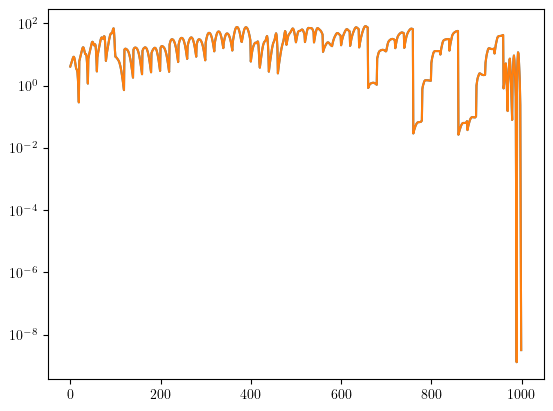

In [266]:
pl.figure()
pl.plot(Cl_all/np.sqrt(np.diag(cov_mat_all)))
pl.plot(Cl_scaled/np.sqrt(np.diag(cov_mat_scaled)))
pl.yscale('log')



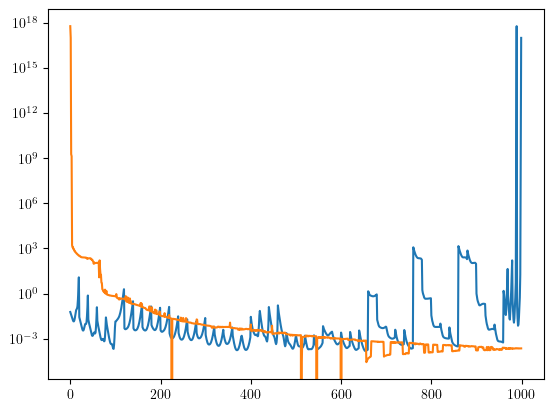

In [267]:
eig_vals = np.linalg.eigvals(cov_mat_scaled)
pl.figure()
pl.plot(np.diag(cov_mat_scaled))
pl.plot(eig_vals)
pl.yscale('log')



2.150861670625753e+22
[[ 2.45216349e-01  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 1.10241986e-01  1.89135234e-01  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 1.03213303e-01  7.07010227e-02  1.54276021e-01 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 ...
 [-6.60300091e-15 -5.87759936e-15 -5.44984789e-15 ...  4.26679087e+00
   0.00000000e+00  0.00000000e+00]
 [-1.55017726e-06  3.39673694e-07  2.41609500e-07 ... -2.53546124e-18
   3.68866940e+04  0.00000000e+00]
 [-7.75676362e+01  7.48503071e+01  4.99945370e+01 ... -1.20729982e-12
  -5.42637710e-09  3.14279433e+08]]
(-0.19241176560857154+0j)


(0.0, 1000.0)

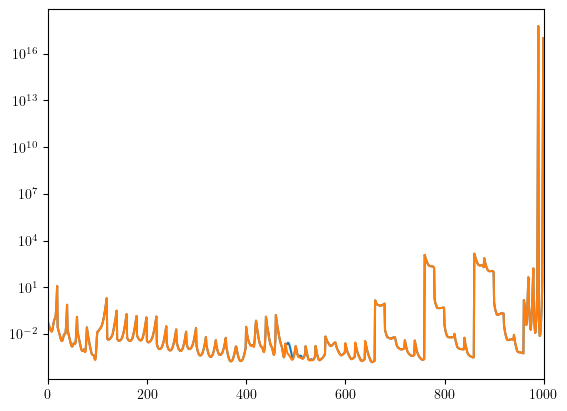

In [268]:
cov_total_origp = np.copy(cov_mat_scaled)
# cov_total = 0.5*(cov_total + cov_total.T)
eigenvalues, eigenvectors = np.linalg.eig(cov_mat_scaled)
epsilon = 1e-5
# clipped_eigenvalues = (np.maximum((eigenvalues), epsilon))
clipped_eigenvalues = np.abs(eigenvalues)
# print(np.amin(clipped_eigenvalues))
cov_total = eigenvectors @ np.diag(clipped_eigenvalues) @ eigenvectors.T
# cov_total = 0.5*(cov_total + cov_total.T)
cov_total = np.real(cov_total)
# np.fill_diagonal(cov_total, np.diag(cov_total_origp))
cov_total = 0.5*(cov_total + cov_total.T)
print(np.linalg.cond(cov_total))
print(np.linalg.cholesky(cov_total))

eigvals = jnp.linalg.eigvals(cov_total)
print(jnp.amin(eigvals))
P_total = jnp.linalg.inv(cov_total)
# print(jnp.linalg.cond(cov_total))
pl.figure()
# pl.plot(np.diag(cov_total)/np.diag(cov_total_orig))
pl.plot(np.diag(cov_total))
pl.plot(np.diag(cov_total_origp))
pl.yscale('log')
pl.xlim(0, 1000)
# pl.ylim(1e-37, 1e-25)




/u/spandey3/myjax/lib/python3.10/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/u/spandey3/myjax/lib/python3.10/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


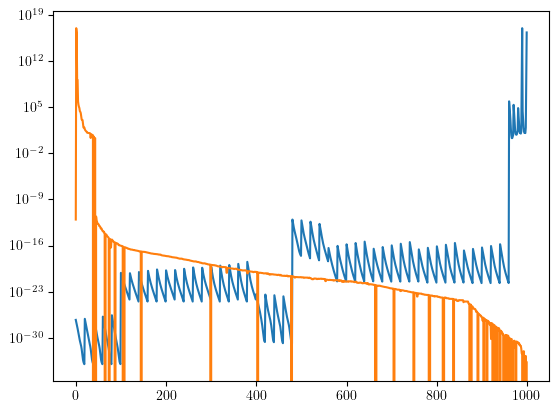

In [269]:
# probes_all
eig_vals = np.linalg.eigvals(cov_mat_all)
pl.figure()
pl.plot(np.diag(cov_mat_all))
pl.plot(eig_vals)
pl.yscale('log')



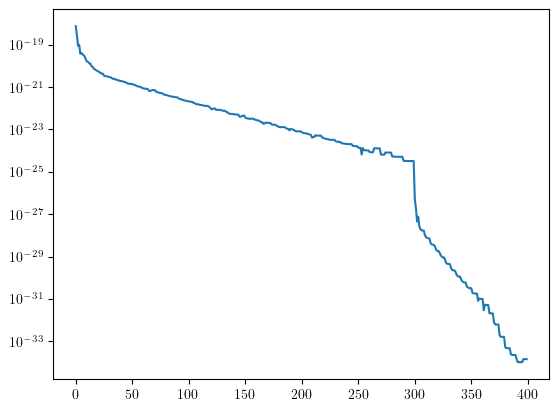

In [270]:
pl.figure()
pl.plot((np.linalg.eigvals(cov_mat_all[:400,:400])))
pl.yscale('log')



In [271]:
# Cl_all.shape, cov_mat_all.shape

probes_all



['ky', 'kk', 'gy', 'gg', 'gk', 'ge']

In [61]:
# save DV:
saved = {'ell_array':l_array_survey, 'k_array':analysis_dict['k_array_survey'], 
         'Cl_Pk':Cl_all, 'cov_mat':cov_mat_all, 'probes':probes_all, 
         'edges_left':ell_edge_left, 'edges_right':ell_edge_right,
         'bin_comb_all_wprobe':bin_comb_all_wprobe}
# pk.dump(saved, open(abs_path_data + '/pge/DV_fid_Cl_Pk_cov_mthresh_hod_v3.pk','wb'))
pk.dump(saved, open(abs_path_data + '/pge/DV_fid_Cl_Pk_cov_mthresh_hod_v5_symb_dataconsist.pk','wb'))



(850.0, 940.0)

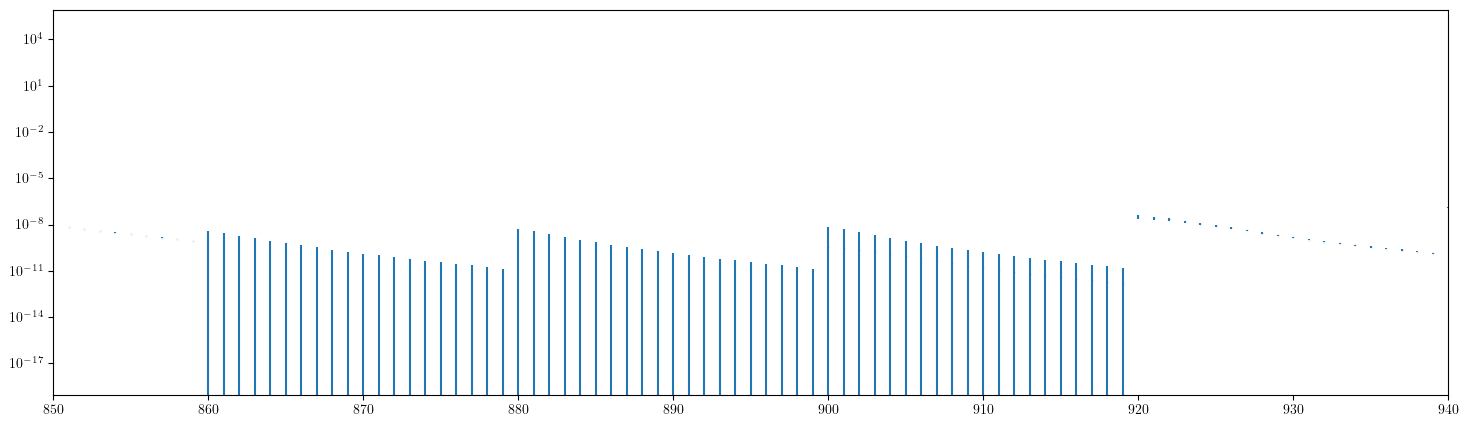

In [31]:
pl.figure(figsize=(18,5))
pl.errorbar(np.arange(nell_all + nbl*nk), Cl_all, yerr=np.sqrt(np.diag(cov_mat_all)), fmt='o', markersize=0.1)
pl.yscale('log')
# pl.xlim(1300,1400)
pl.xlim(850,940)




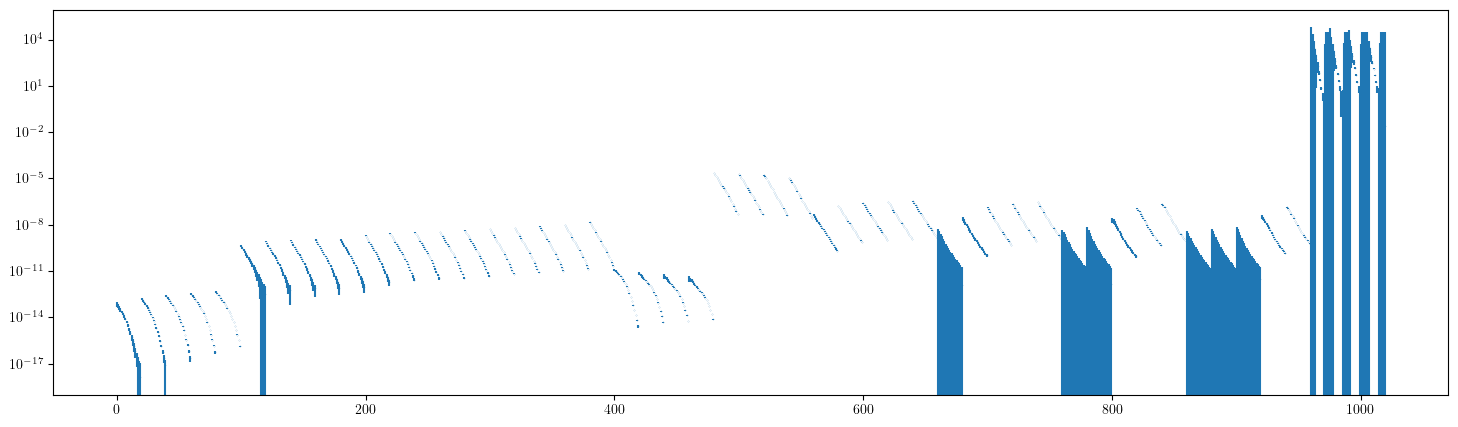

In [27]:
pl.figure(figsize=(18,5))
pl.errorbar(np.arange(nell_all + nbl*nk), Cl_all, yerr=np.sqrt(np.diag(cov_mat_all)), fmt='o', markersize=0.1)
pl.yscale('log')
# pl.xlim(1000,1200)



In [129]:
# cov_test.covtot_dict.keys()
cov_test.Cl_result_dict['gg']['bin_1_1'].keys()


dict_keys(['tot_ellsurvey', 'tot_plus_noise_ellsurvey'])

In [225]:
M_array = jnp.logspace(11, 16, 10)
val = 1e13
jnp.where(M_array > val, 1, 0)   


Array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1], dtype=int64, weak_type=True)

In [227]:
(-1)**1.5

(-1.8369701987210297e-16-1j)

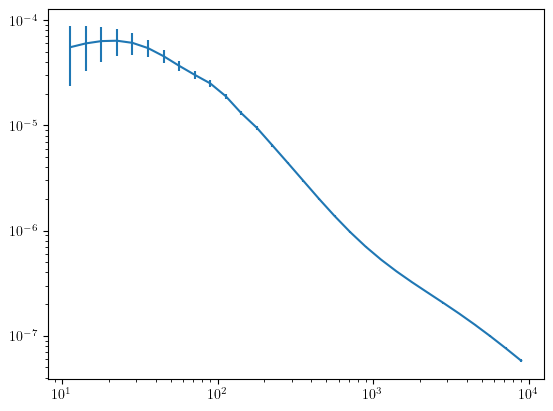

In [130]:
pl.figure()
pl.errorbar(cov_test.Cl_result_dict['l_array_survey'],cov_test.Cl_result_dict['gg']['bin_1_1']['tot_ellsurvey'],np.sqrt(np.diag(cov_test.covtot_dict['gg_gg']['bin_1_1_1_1'])) )
pl.xscale('log')
pl.yscale('log')




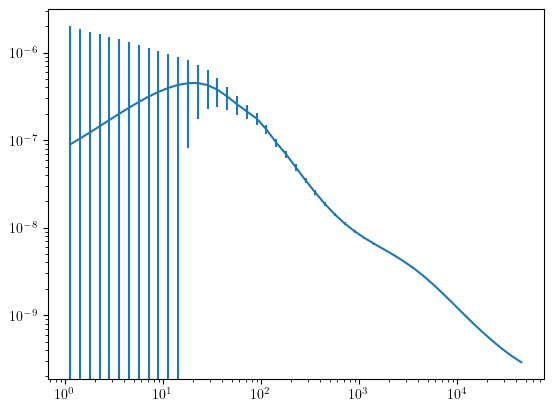

In [ ]:
pl.figure()
pl.errorbar(cov_test.Cl_result_dict['l_array_survey'],cov_test.Cl_result_dict['gk']['bin_1_3']['tot_ellsurvey'],np.sqrt(np.diag(cov_test.covtot_dict['gk_gk']['bin_1_3_1_3'])) )
pl.xscale('log')
pl.yscale('log')




(1e-14, 1e-10)

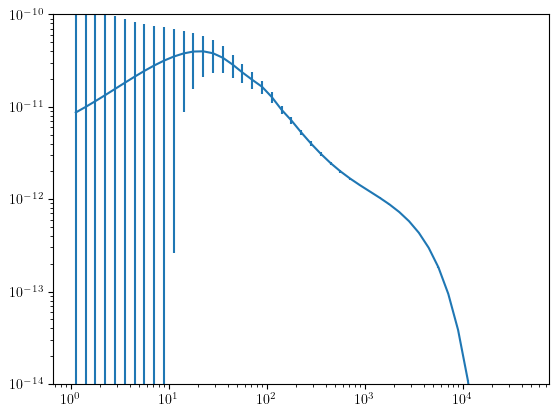

In [52]:
ell = cov_test.Cl_result_dict['l_array_survey']
pl.figure()
pl.errorbar(ell,cov_test.Cl_result_dict['gy']['bin_1_0']['tot_ellsurvey'],np.sqrt(np.diag(cov_test.covtot_dict['gy_gy']['bin_1_0_1_0'])) )
pl.xscale('log')
pl.yscale('log')
pl.ylim(1e-14, 1e-10)




(1e-18, 1e-11)

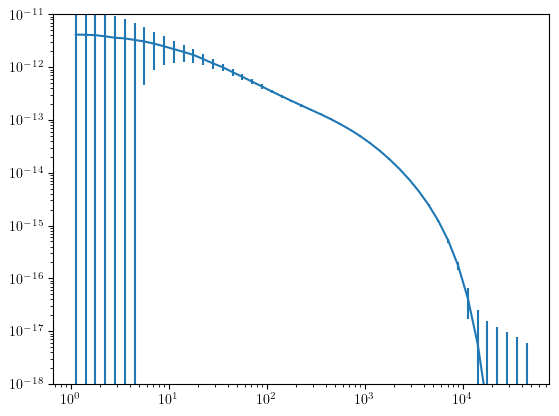

In [54]:
ell = cov_test.Cl_result_dict['l_array_survey']
pl.figure()
pl.errorbar(ell,cov_test.Cl_result_dict['ky']['bin_1_0']['tot_ellsurvey'],np.sqrt(np.diag(cov_test.covtot_dict['ky_ky']['bin_1_0_1_0'])) )
pl.xscale('log')
pl.yscale('log')
pl.ylim(1e-18, 1e-11)




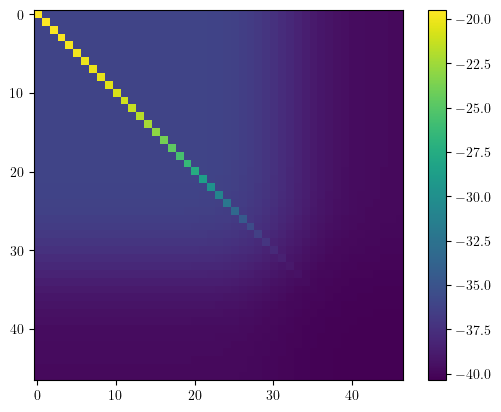

In [48]:
pl.figure()
pl.imshow(np.log(np.abs(cov_test.covtot_dict['gg_gg']['bin_1_1_1_1'])))
pl.colorbar()
pl.show()


